In [3]:
import pandas as pd

df = pd.read_csv("../data/personality_dataset.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

Matplotlib is building the font cache; this may take a moment.


In [5]:
# Load dataset

df = pd.read_csv('../data/personality_dataset.csv')

print(df.head())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0            6.0   
1               9.0        Yes                      0.0            0.0   
2               9.0        Yes                      1.0            2.0   
3               0.0         No                      6.0            7.0   
4               3.0         No                      9.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4                        No                  8.0             5.0   Extrovert  


In [6]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB
None
       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2837.000000              2838.000000    2834.000000   
mean           4.505816                 3.963354       3.000000   
std            3.479192                 2.903827       2.247327   
min            0.00000

In [7]:
binary_map = {
    'Yes': 1,
    'No': 0
}

df['Stage_fear'] = df['Stage_fear'].map(binary_map)
df['Drained_after_socializing'] = df['Drained_after_socializing'].map(binary_map)

In [8]:
target_map = {
    'Introvert': 0,
    'Extrovert': 1
}

df['Personality'] = df['Personality'].map(target_map)

In [9]:
# Social energy score

df['social_energy_score'] = (
    df['Social_event_attendance'] +
    df['Going_outside'] +
    df['Friends_circle_size'] +
    df['Post_frequency']
) - df['Time_spent_Alone']

# Isolation ratio

df['isolation_ratio'] = (
    df['Time_spent_Alone'] /
    (df['Friends_circle_size'] + 1)
)

# Outdoor social score

df['outdoor_social_score'] = (
    df['Going_outside'] *
    df['Social_event_attendance']
)

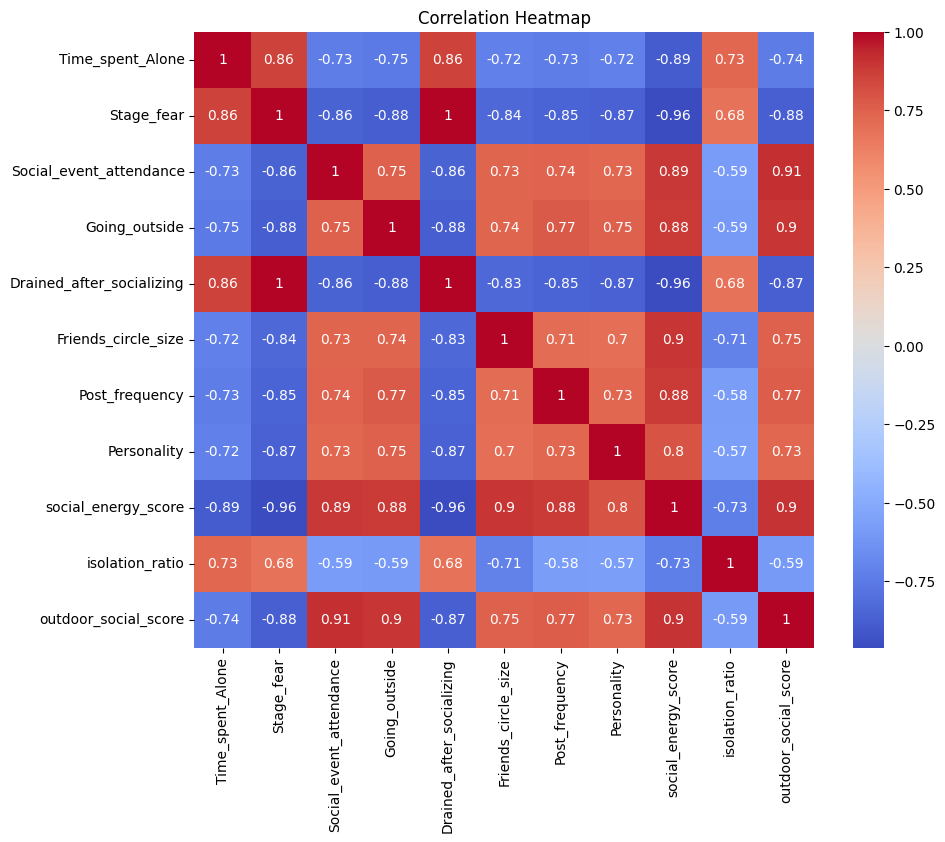

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
X = df.drop('Personality', axis=1)
y = df['Personality']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
numerical_features = X.columns.tolist()

In [14]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features)
])

In [15]:
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

logistic_pipeline.fit(X_train, y_train)

log_preds = logistic_pipeline.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, log_preds))




Logistic Regression Accuracy: 0.9155172413793103


In [16]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.906896551724138


In [17]:
catboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        verbose=0,
        random_state=42
    ))
])

In [18]:
param_grid = {
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__iterations': [100, 200, 300]
}

search = RandomizedSearchCV(
    catboost_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print('Best Parameters:', search.best_params_)

d:\mine\introvert-extrovert-ml\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
7 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "d:\mine\introvert-extrovert-ml\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\mine\introvert-extrovert-ml\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\mine\introvert-extrovert-ml\venv\Lib\site-packages\sklearn\pipeline.py", line

Best Parameters: {'classifier__learning_rate': 0.01, 'classifier__iterations': 100, 'classifier__depth': 6}


In [19]:
predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, predictions))
print('F1 Score:', f1_score(y_test, predictions))
print('ROC AUC:', roc_auc_score(y_test, probabilities))

print('\nClassification Report:\n')
print(classification_report(y_test, predictions))

Accuracy: 0.9241379310344827
F1 Score: 0.9251700680272109
ROC AUC: 0.9490991955828454

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92       282
           1       0.94      0.91      0.93       298

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



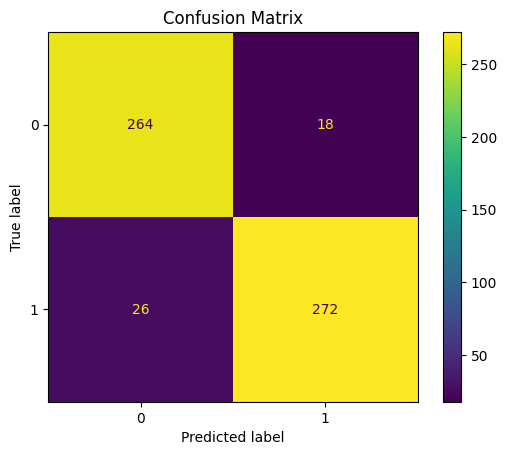

In [20]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print('Cross Validation Accuracy:', scores.mean())

Cross Validation Accuracy: 0.9344827586206896


In [26]:
joblib.dump(best_model, '../saved_models/personality_pipeline.pkl')

print('Model saved successfully!')

Model saved successfully!


In [52]:
import joblib
import pandas as pd
import random

# Load trained model
model = joblib.load("../saved_models/personality_pipeline.pkl")

# Generate random test data
sample_data = {
    "Time_spent_Alone": random.randint(0, 10),
    "Stage_fear": random.choice([0, 1]),
    "Social_event_attendance": random.randint(0, 10),
    "Going_outside": random.randint(0, 10),
    "Drained_after_socializing": random.choice([0, 1]),
    "Friends_circle_size": random.randint(0, 20),
    "Post_frequency": random.randint(0, 10)
}

# Convert to dataframe
df = pd.DataFrame([sample_data])

# Feature engineering
df['social_energy_score'] = (
    df['Social_event_attendance'] +
    df['Going_outside'] +
    df['Friends_circle_size'] +
    df['Post_frequency']
) - df['Time_spent_Alone']

df['isolation_ratio'] = (
    df['Time_spent_Alone'] /
    (df['Friends_circle_size'] + 1)
)

df['outdoor_social_score'] = (
    df['Going_outside'] *
    df['Social_event_attendance']
)

# Predict
prediction = model.predict(df)[0]
probability = model.predict_proba(df)[0].max()

label = "Extrovert" if prediction == 1 else "Introvert"

print("\nRandom Test Input:")
print(sample_data)

print("\nPrediction:")
print(label)

print("\nConfidence:")
print(round(float(probability), 4))


Random Test Input:
{'Time_spent_Alone': 0, 'Stage_fear': 0, 'Social_event_attendance': 10, 'Going_outside': 7, 'Drained_after_socializing': 1, 'Friends_circle_size': 18, 'Post_frequency': 6}

Prediction:
Extrovert

Confidence:
0.6325
